# Mini-Projet NLP : Transformers et Système RAG

Ce notebook présente une exploration pratique des modèles **Transformers** pour différentes tâches de traitement automatique du langage naturel, puis l’implémentation d’un système **RAG** simple permettant d’améliorer les réponses d’un modèle de langage à l’aide d’un corpus externe.

Le projet est divisé en deux grandes parties :

1. Exploration des Transformers et tâches NLP.
2. Systèmes RAG (Retrieval-Augmented Generation).

## Environnement et bibliothèques utilisées

Dans ce notebook, nous utiliserons principalement les bibliothèques suivantes :

* `transformers` : pour charger et utiliser des modèles pré-entraînés.
* `sentence-transformers` : pour générer les embeddings des documents et des requêtes.
* `faiss` : pour indexer les embeddings et effectuer une recherche de similarité.
* `torch` : pour l’exécution des modèles de deep learning.
* `pandas` et `numpy` : pour la manipulation des données.
* `PyPDF2` ou `pypdf` : pour lire le contenu des documents PDF si nécessaire.

Ces bibliothèques permettent de construire une chaîne complète allant du traitement du texte jusqu’à la génération de réponses augmentées par des documents externes.

## Partie 1 : Exploration des Transformers et tâches NLP

Les Transformers sont des architectures de deep learning très utilisées en NLP.  
Ils permettent de traiter du texte en capturant les relations entre les mots grâce au mécanisme d’attention.

Dans cette partie, nous allons utiliser des modèles pré-entraînés disponibles sur HuggingFace afin de réaliser plusieurs tâches NLP sans entraîner un modèle depuis zéro.

In [28]:
# Installation des bibliothèques nécessaires
!pip install datasets accelerate
!pip install -q transformers==4.44.2

## 1-a Importation des bibliothèques

In [29]:
import torch
from transformers import AutoTokenizer, AutoModel, pipeline

device = 0 if torch.cuda.is_available() else -1

print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nom du GPU :", torch.cuda.get_device_name(0))

GPU disponible : True
Nom du GPU : Tesla T4


## 1-b Exploration du tokenizer et du modèle Transformer

Avant d’utiliser les pipelines simplifiés, il est important de comprendre comment un modèle Transformer reçoit le texte.

Un modèle Transformer ne comprend pas directement les phrases sous forme de texte brut.

Le texte passe d’abord par un tokenizer :

Texte brut → Tokens → Identifiants numériques → Modèle Transformer

Le tokenizer découpe le texte en mots ou sous-mots, puis transforme ces éléments en nombres appelés `input_ids`.

In [30]:
# Modèle BERT adapté au français
model_name = "dbmdz/bert-base-french-europeana-cased"

# Chargement du tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Chargement du modèle
model = AutoModel.from_pretrained(model_name)

# Exemple de phrase
texte = "Les architectures Transformers ont révolutionné le traitement du langage naturel."

# Encodage du texte
inputs = tokenizer(texte, return_tensors="pt")

print("Texte original :")
print(texte)

print("\nTokens générés :")
print(tokenizer.tokenize(texte))

print("\nIdentifiants numériques des tokens :")
print(inputs["input_ids"])

# Passage dans le modèle
outputs = model(**inputs)

print("\nForme de la dernière couche cachée :")
print(outputs.last_hidden_state.shape)

Texte original :
Les architectures Transformers ont révolutionné le traitement du langage naturel.

Tokens générés :
['Les', 'architecture', '##s', 'Trans', '##for', '##mers', 'ont', 'révolution', '##né', 'le', 'traitement', 'du', 'langage', 'naturel', '.']

Identifiants numériques des tokens :
tensor([[    2,   519, 21475,   212,  4627,  3599, 26552,   507,  3663,  1187,
           354,  5153,   378,  7373,  6713,    18,     3]])

Forme de la dernière couche cachée :
torch.Size([1, 17, 768])


###  Visualisation : Heatmap d'attention BERT

Le mécanisme d'attention permet au modèle de pondérer l'importance de chaque token par rapport aux autres.

La heatmap suivante montre les poids d'attention de la dernière couche du modèle BERT.
Plus une case est foncée, plus le modèle accorde d'importance à la relation entre les deux tokens correspondants.

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


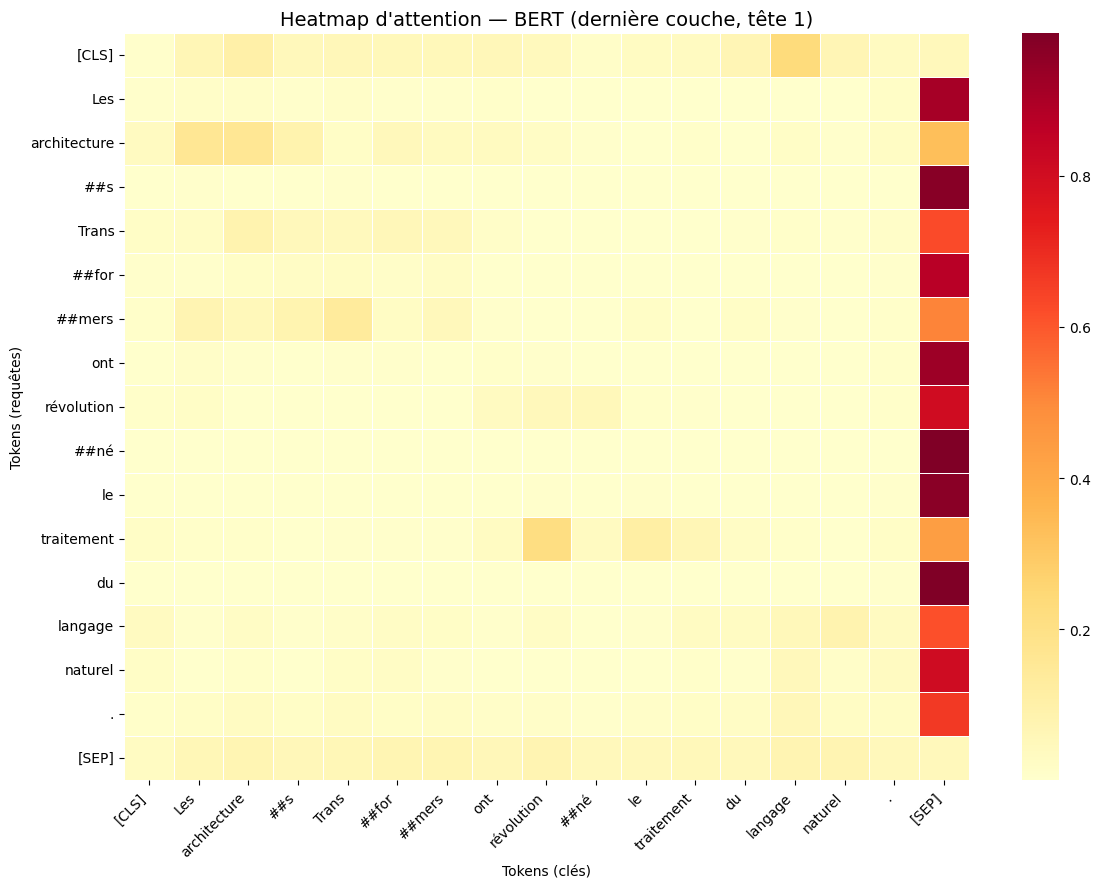

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction des poids d'attention
outputs_att = model(**inputs, output_attentions=True)
attention = outputs_att.attentions[-1][0, 0].detach().numpy()  # dernière couche, tête 1

tokens_list = ["[CLS]"] + tokenizer.tokenize(texte) + ["[SEP]"]

plt.figure(figsize=(12, 9))
sns.heatmap(
    attention[:len(tokens_list), :len(tokens_list)],
    xticklabels=tokens_list,
    yticklabels=tokens_list,
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Heatmap d'attention — BERT (dernière couche, tête 1)", fontsize=14)
plt.xlabel("Tokens (clés)")
plt.ylabel("Tokens (requêtes)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 1-c-0 Utilisation des pipelines HuggingFace

HuggingFace propose une fonction appelée `pipeline`.

Cette fonction permet d’utiliser facilement des modèles pré-entraînés pour différentes tâches NLP, sans écrire manuellement toutes les étapes internes.

Dans cette partie, nous testons quatre tâches :

1. Analyse de sentiment
2. Classification de texte
3. Question Answering
4. Résumé automatique

## 1-c-1 Analyse de sentiment

L’analyse de sentiment consiste à déterminer l’opinion exprimée dans un texte.

Le résultat peut être positif, négatif ou parfois neutre selon le modèle utilisé.

Exemple :

Texte : "Ce projet est intéressant."  
Résultat attendu : sentiment positif

In [32]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device
)

textes = [
    "Ce film est absolument magnifique !",
    "Je n'ai pas du tout aimé cette expérience.",
]

for texte in textes:
    result = sentiment_pipeline(texte)
    print(f"Texte   : {texte}")
    print(f"Sentiment label : {result[0]['label']} , score : {result[0]['score']:.4f}\n")


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Texte   : Ce film est absolument magnifique !
Sentiment label : positive , score : 0.9395

Texte   : Je n'ai pas du tout aimé cette expérience.
Sentiment label : negative , score : 0.8531



### Analyse du résultat

Le modèle retourne généralement deux informations :

- `label` : la classe prédite, par exemple positif ou négatif.
- `score` : le niveau de confiance du modèle.

Plus le score est proche de 1, plus le modèle est confiant dans sa prédiction.

###  Visualisation : Scores d'analyse de sentiment

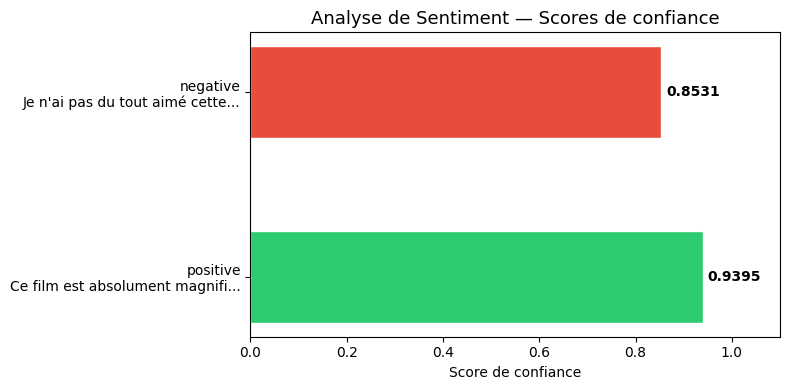

In [33]:
import matplotlib.pyplot as plt

# Re-analyse pour récupérer les résultats
textes_sentiment = [
    "Ce film est absolument magnifique !",
    "Je n'ai pas du tout aimé cette expérience.",
]

resultats_sentiment = [sentiment_pipeline(t)[0] for t in textes_sentiment]

labels_sent = [f"{r['label']}\n{t[:30]}..." for r, t in zip(resultats_sentiment, textes_sentiment)]
scores_sent = [r['score'] for r in resultats_sentiment]
colors_sent = ["#2ecc71" if r['label'] == 'positive' else "#e74c3c" for r in resultats_sentiment]

plt.figure(figsize=(8, 4))
bars = plt.barh(labels_sent, scores_sent, color=colors_sent, edgecolor='white', height=0.5)

for bar, score in zip(bars, scores_sent):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontweight='bold')

plt.xlim(0, 1.1)
plt.xlabel("Score de confiance")
plt.title("Analyse de Sentiment — Scores de confiance", fontsize=13)
plt.tight_layout()
plt.show()

## 1-c-2 Classification de texte

La classification de texte consiste à attribuer une catégorie à un texte.

Dans cette expérience, nous utilisons la classification zero-shot.

Le zero-shot classification permet de classer un texte dans des catégories choisies sans entraîner un nouveau modèle.

In [34]:
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

texte_a_classer = "L'équipe de développement a déployé une nouvelle base de données vectorielle ce matin."

labels_possibles = [
    "informatique",
    "sport",
    "économie",
    "politique"
]

resultat_classification = classifier(
    texte_a_classer,
    candidate_labels=labels_possibles
)

print("--- Classification de Texte ---")
print("Texte à classer : ",texte_a_classer)

print("\nRésultats :")
for label, score in zip(resultat_classification["labels"], resultat_classification["scores"]):
    print(f"{label} : {score:.4f}")

--- Classification de Texte ---
Texte à classer :  L'équipe de développement a déployé une nouvelle base de données vectorielle ce matin.

Résultats :
informatique : 0.6961
politique : 0.1372
économie : 0.1362
sport : 0.0305


### Analyse du résultat

Le modèle compare le texte avec chaque label proposé.

Il retourne les labels triés selon leur probabilité.

Dans notre exemple, le label le plus logique devrait être `informatique`, car le texte parle de développement et de base de données vectorielle.

### Visualisation : Scores de classification zero-shot

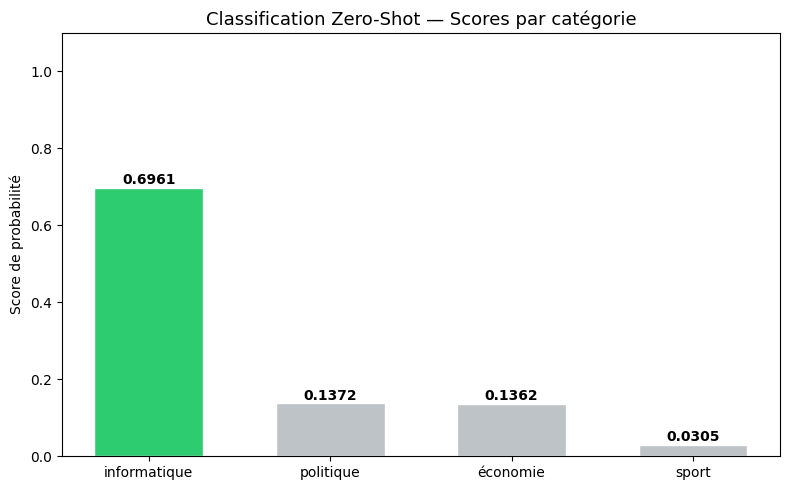

In [35]:
import matplotlib.pyplot as plt

labels_cls = resultat_classification["labels"]
scores_cls = resultat_classification["scores"]

# Couleurs : le meilleur en vert, les autres en gris
colors_cls = ["#2ecc71" if i == 0 else "#bdc3c7" for i in range(len(labels_cls))]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels_cls, scores_cls, color=colors_cls, edgecolor='white', width=0.6)

for bar, score in zip(bars, scores_cls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontweight='bold')

plt.ylabel("Score de probabilité")
plt.title("Classification Zero-Shot — Scores par catégorie", fontsize=13)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

## 1-c-3 Question Answering

Le Question Answering consiste à répondre à une question à partir d’un contexte donné.

Le modèle ne répond pas librement : il cherche la réponse dans le texte fourni.

In [36]:
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/xlm-roberta-base-squad2",
    device=device
)

contexte = """
L'École Nationale des Sciences Appliquées d'Al Hoceima propose une filière en Ingénierie des Données.
Au cours de la deuxième année, les étudiants réalisent un mini-projet portant sur l'exploration des modèles Transformers
et la mise en œuvre de systèmes de génération augmentée par récupération, appelés systèmes RAG.
"""

question = "Quel est le sujet du mini-projet ?"

reponse = qa_pipeline(
    question=question,
    context=contexte
)

print("Question :", question)
print("Réponse extraite :", reponse["answer"])
print("Score de confiance :", round(reponse["score"], 4))

Question : Quel est le sujet du mini-projet ?
Réponse extraite :  l'exploration des modèles Transformers
Score de confiance : 0.2988


### Analyse du résultat

Le modèle lit le contexte fourni, puis extrait la partie du texte qui répond le mieux à la question.

Le score indique la confiance du modèle.

Cette tâche montre que le modèle peut répondre correctement lorsqu’on lui donne un contexte pertinent.

## 1-c-4 Résumé automatique

Le résumé automatique consiste à produire une version courte d’un texte long.

L’objectif est de conserver les idées principales tout en réduisant la taille du texte.

Cette tâche est utile pour :

- Résumer des articles.
- Résumer des documents PDF.
- Extraire les informations importantes d’un corpus.

In [37]:
summarizer = pipeline(
    "summarization",
    model="lincoln/mbart-mlsum-automatic-summarization",
    device=device
)
texte_long = """
Le traitement du langage naturel a franchi un cap important avec l'introduction de l'architecture Transformer en 2017.
Contrairement aux réseaux récurrents traditionnels, qui traitent les mots de manière séquentielle,
les Transformers s'appuient sur un mécanisme d'attention. Ce mécanisme permet au modèle d'analyser les relations
entre tous les mots d'une phrase simultanément. Cette innovation a facilité l'entraînement de grands modèles de langage
sur des volumes massifs de données, ouvrant la voie aux modèles modernes utilisés dans la traduction automatique,
la génération de texte, le question answering et les systèmes RAG.
"""

resume = summarizer(
    texte_long,
    max_length=70,
    min_length=25,
    do_sample=False
)

print("Texte original :")
print(texte_long)

print("\nRésumé généré :")
print(resume[0]["summary_text"])

Texte original :

Le traitement du langage naturel a franchi un cap important avec l'introduction de l'architecture Transformer en 2017.
Contrairement aux réseaux récurrents traditionnels, qui traitent les mots de manière séquentielle,
les Transformers s'appuient sur un mécanisme d'attention. Ce mécanisme permet au modèle d'analyser les relations
entre tous les mots d'une phrase simultanément. Cette innovation a facilité l'entraînement de grands modèles de langage
sur des volumes massifs de données, ouvrant la voie aux modèles modernes utilisés dans la traduction automatique,
la génération de texte, le question answering et les systèmes RAG.


Résumé généré :
Le traitement du langage naturel a franchi un cap important avec l'introduction de l'architecture Transformer en 2017.


### Analyse du résultat

Le modèle de résumé automatique produit une version plus courte du texte initial.

Un bon résumé doit :

- Garder les idées principales.
- Supprimer les détails secondaires.
- Rester cohérent et compréhensible.

### Visualisation : Taux de compression du résumé

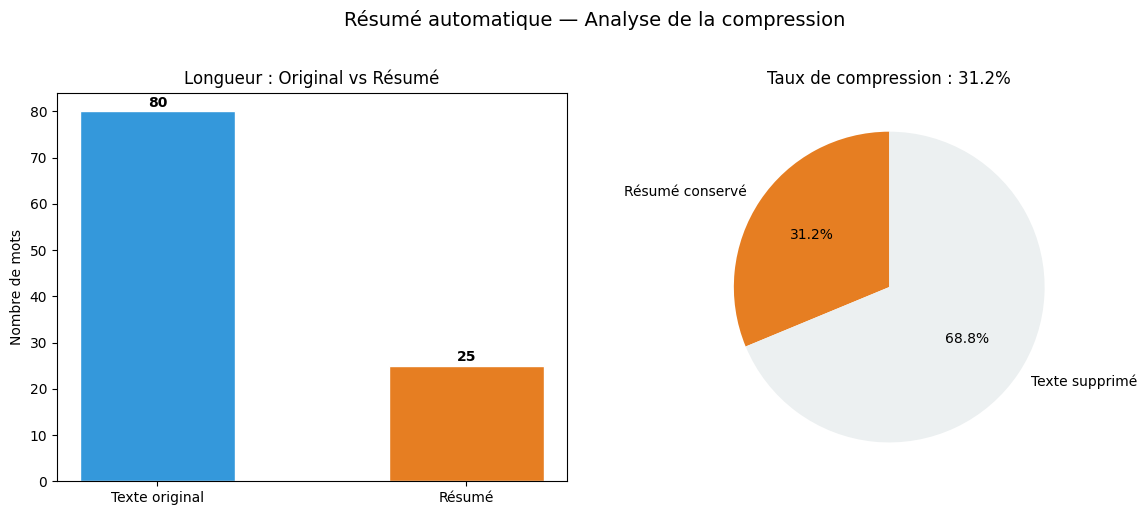

In [38]:
import matplotlib.pyplot as plt

# Récupération du texte et du résumé depuis les variables existantes
try:
    original_len = len(texte_long.split())
    resume_text = summarizer(texte_long, max_length=60, min_length=20, do_sample=False)[0]['summary_text']
    resume_len = len(resume_text.split())
except:
    original_len = 80  # valeur approximative
    resume_len = 25

taux_compression = resume_len / original_len

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Barplot comparatif
ax1.bar(["Texte original", "Résumé"], [original_len, resume_len],
        color=["#3498db", "#e67e22"], edgecolor='white', width=0.5)
ax1.set_ylabel("Nombre de mots")
ax1.set_title("Longueur : Original vs Résumé")

for i, v in enumerate([original_len, resume_len]):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart du taux de compression
ax2.pie([resume_len, original_len - resume_len],
        labels=["Résumé conservé", "Texte supprimé"],
        colors=["#e67e22", "#ecf0f1"],
        autopct='%1.1f%%', startangle=90)
ax2.set_title(f"Taux de compression : {taux_compression:.1%}")

plt.suptitle("Résumé automatique — Analyse de la compression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Partie 2 : Systèmes RAG (Retrieval-Augmented Generation)

Dans cette partie, nous allons implémenter un système RAG simple.

L'objectif est de permettre à un modèle génératif de répondre à des questions en utilisant un corpus externe.

**Au lieu d'utiliser un fichier PDF**, nous utilisons ici un **dataset simplifié** défini directement dans le code.
Ce corpus contient des passages sur l'intelligence artificielle, le NLP, les Transformers et les systèmes RAG.

Le pipeline contient les étapes suivantes :

1. Définir un corpus de documents (dataset simplifié).
2. Découper le texte en petits morceaux appelés chunks.
3. Transformer chaque chunk en embedding.
4. Indexer les embeddings avec FAISS.
5. Transformer la question utilisateur en embedding.
6. Rechercher les chunks les plus pertinents.
7. Construire un prompt augmenté.
8. Générer une réponse avec un modèle génératif.
9. Comparer les réponses avec et sans RAG.

In [39]:
# Installation des bibliothèques nécessaires
!pip install -q sentence-transformers faiss-cpu transformers accelerate

## 2-a Importation des bibliothèques

In [40]:
import numpy as np
import faiss
import torch

from sentence_transformers import SentenceTransformer
from transformers import pipeline

## 2-b Définition du corpus simplifié

Dans un système RAG, le corpus représente la base de connaissances externe.

Ici, nous définissons un dataset simplifié composé de plusieurs passages thématiques.
Chaque passage couvre un sujet lié à l'IA, au NLP, aux Transformers ou aux systèmes RAG.

Ce corpus remplace l'utilisation d'un fichier PDF et permet de tester le système RAG de manière autonome.

In [41]:
# Dataset simplifié : corpus de connaissances sur l'IA et le NLP
corpus_documents = [
    # --- Documents sur les Transformers ---
    """Les Transformers sont une architecture de réseau de neurones introduite en 2017 par Vaswani et al. """
    """dans l'article 'Attention is All You Need'. Contrairement aux réseaux récurrents (RNN, LSTM), """
    """les Transformers utilisent un mécanisme d'attention qui permet de traiter toutes les positions """
    """d'une séquence en parallèle. Cette parallélisation rend l'entraînement beaucoup plus rapide. """
    """L'architecture se compose d'un encodeur et d'un décodeur, chacun empilant plusieurs couches """
    """d'attention multi-têtes et de réseaux feed-forward.""",

    """Le mécanisme d'attention multi-têtes (Multi-Head Attention) est le composant central des Transformers. """
    """Il calcule trois matrices : Query (Q), Key (K) et Value (V) à partir des embeddings d'entrée. """
    """L'attention est calculée par la formule : Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V. """
    """Les têtes multiples permettent au modèle de capturer différents types de relations entre les mots """
    """simultanément, comme les relations syntaxiques et sémantiques.""",

    # --- Documents sur BERT ---
    """BERT (Bidirectional Encoder Representations from Transformers) est un modèle pré-entraîné développé """
    """par Google en 2018. BERT utilise uniquement la partie encodeur du Transformer. Il est pré-entraîné """
    """avec deux objectifs : le Masked Language Model (MLM), où 15% des tokens sont masqués et le modèle """
    """doit les prédire, et le Next Sentence Prediction (NSP), où le modèle apprend à prédire si deux """
    """phrases sont consécutives. BERT est bidirectionnel, ce qui lui permet de comprendre le contexte """
    """des deux côtés d'un mot.""",

    # --- Documents sur GPT ---
    """GPT (Generative Pre-trained Transformer) est une famille de modèles développée par OpenAI. """
    """Contrairement à BERT, GPT utilise uniquement la partie décodeur du Transformer et est un modèle """
    """autorégressif : il génère du texte token par token, de gauche à droite. GPT-2 a 1.5 milliard de """
    """paramètres, GPT-3 en a 175 milliards, et GPT-4 est un modèle multimodal encore plus puissant. """
    """Ces modèles excellent dans la génération de texte, la traduction et le résumé automatique.""",

    # --- Documents sur le RAG ---
    """Le RAG (Retrieval-Augmented Generation) est une approche qui combine la recherche d'information """
    """et la génération de texte. Un système RAG fonctionne en deux étapes principales : d'abord, il """
    """recherche des documents pertinents dans une base de connaissances externe à l'aide d'embeddings """
    """et d'une recherche vectorielle. Ensuite, il utilise ces documents comme contexte pour un modèle """
    """de langage génératif (LLM) qui produit une réponse basée sur ces informations récupérées.""",

    """Les avantages du RAG par rapport au fine-tuning sont nombreux. Le fine-tuning nécessite de """
    """ré-entraîner le modèle sur de nouvelles données, ce qui est coûteux en temps et en ressources. """
    """Le RAG permet de mettre à jour la base de connaissances sans toucher au modèle. De plus, le RAG """
    """réduit les hallucinations car le modèle s'appuie sur des documents réels. Le prompt engineering """
    """est une autre alternative, mais il est limité par la taille du contexte du modèle.""",

    """Le pipeline complet d'un système RAG comprend six étapes : (1) l'encodage des documents du corpus """
    """sous forme d'embeddings vectoriels, (2) l'indexation de ces embeddings dans une base vectorielle """
    """comme FAISS, (3) l'encodage de la requête utilisateur en embedding, (4) la recherche des top-k """
    """documents les plus similaires, (5) la construction d'un prompt augmenté contenant le contexte """
    """récupéré et la question, et (6) la génération de la réponse par le LLM.""",

    # --- Documents sur les embeddings ---
    """Les embeddings sont des représentations vectorielles denses de textes dans un espace à haute """
    """dimension. Les modèles comme Sentence-BERT génèrent des embeddings de phrases entières. Deux """
    """textes sémantiquement proches ont des embeddings proches dans l'espace vectoriel (mesurés par """
    """la similarité cosinus ou la distance euclidienne). Ces embeddings sont essentiels pour la """
    """recherche sémantique, le clustering de textes et les systèmes de recommandation.""",

    # --- Documents sur FAISS ---
    """FAISS (Facebook AI Similarity Search) est une bibliothèque développée par Meta pour la recherche """
    """de similarité efficace dans de grands ensembles de vecteurs. FAISS supporte plusieurs types """
    """d'index : IndexFlatL2 pour la recherche exacte par distance euclidienne, IndexIVFFlat pour """
    """une recherche approximative plus rapide, et IndexHNSW pour les graphes de proximité. FAISS """
    """peut gérer des millions de vecteurs et supporte l'accélération GPU.""",

    # --- Documents sur les limites des LLMs ---
    """Les LLMs (Large Language Models) sans accès à des données externes ont plusieurs limites. """
    """Premièrement, leurs connaissances sont figées à la date de leur entraînement (knowledge cutoff). """
    """Deuxièmement, ils peuvent produire des hallucinations, c'est-à-dire générer des informations """
    """fausses mais plausibles. Troisièmement, ils ne peuvent pas accéder à des données privées ou """
    """spécifiques à un domaine. Le RAG résout ces problèmes en fournissant un contexte externe actualisé.""",

    # --- Documents sur les variantes RAG ---
    """Il existe plusieurs variantes modernes de l'architecture RAG. Le Naive RAG est la version de base """
    """avec recherche + génération. L'Advanced RAG ajoute des étapes de pré-traitement (reformulation """
    """de requête, re-ranking des résultats). Le Modular RAG décompose le pipeline en modules """
    """interchangeables. Le Self-RAG permet au modèle de décider dynamiquement s'il a besoin de """
    """récupérer des documents ou non. Le Graph RAG utilise des graphes de connaissances au lieu """
    """de simples chunks de texte.""",
]

print(f"Nombre de documents dans le corpus : {len(corpus_documents)}")
print(f"\nAperçu du premier document :")
print(corpus_documents[0][:200] + "...")

Nombre de documents dans le corpus : 11

Aperçu du premier document :
Les Transformers sont une architecture de réseau de neurones introduite en 2017 par Vaswani et al. dans l'article 'Attention is All You Need'. Contrairement aux réseaux récurrents (RNN, LSTM), les Tra...


## 2-c Découpage du texte en chunks

Un modèle d'embeddings ne traite pas efficacement un document entier en une seule fois.

Nous découpons donc le texte en petits morceaux appelés chunks.

Le chevauchement entre les chunks permet d'éviter de perdre une information importante lorsqu'une phrase est coupée entre deux morceaux.

Ici, comme notre dataset est déjà composé de passages courts et thématiques, chaque document constitue naturellement un chunk.

In [42]:
def decouper_texte(texte, mots_par_chunk=80, chevauchement=20):
    mots = texte.split()
    chunks = []

    pas = mots_par_chunk - chevauchement

    for i in range(0, len(mots), pas):
        chunk = " ".join(mots[i:i + mots_par_chunk])

        if len(chunk.strip()) > 0:
            chunks.append(chunk)

    return chunks


# Découpage de tous les documents en chunks
tous_les_chunks = []

for doc in corpus_documents:
    chunks_doc = decouper_texte(doc, mots_par_chunk=80, chevauchement=20)
    tous_les_chunks.extend(chunks_doc)

print(f"Nombre total de chunks créés : {len(tous_les_chunks)}")

print(f"\nExemple de chunk :")
print(tous_les_chunks[0])

Nombre total de chunks créés : 22

Exemple de chunk :
Les Transformers sont une architecture de réseau de neurones introduite en 2017 par Vaswani et al. dans l'article 'Attention is All You Need'. Contrairement aux réseaux récurrents (RNN, LSTM), les Transformers utilisent un mécanisme d'attention qui permet de traiter toutes les positions d'une séquence en parallèle. Cette parallélisation rend l'entraînement beaucoup plus rapide. L'architecture se compose d'un encodeur et d'un décodeur, chacun empilant plusieurs couches d'attention multi-têtes et de réseaux feed-forward.


###  Visualisation : Distribution des tailles de chunks

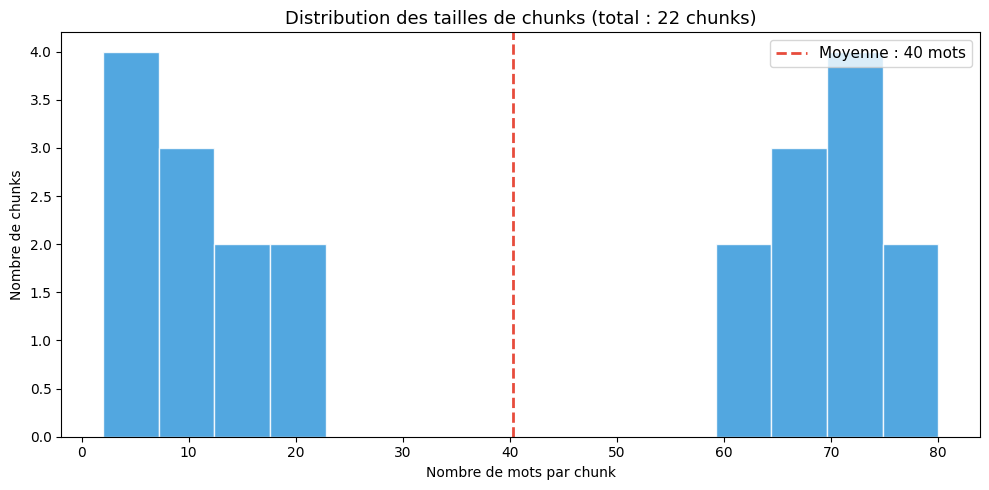

Taille min : 2 mots
Taille max : 80 mots
Taille moyenne : 40.3 mots


In [43]:
import matplotlib.pyplot as plt

chunk_sizes = [len(chunk.split()) for chunk in tous_les_chunks]

plt.figure(figsize=(10, 5))
plt.hist(chunk_sizes, bins=15, color="#3498db", edgecolor="white", alpha=0.85)

mean_size = sum(chunk_sizes) / len(chunk_sizes)
plt.axvline(x=mean_size, color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Moyenne : {mean_size:.0f} mots')

plt.xlabel("Nombre de mots par chunk")
plt.ylabel("Nombre de chunks")
plt.title(f"Distribution des tailles de chunks (total : {len(tous_les_chunks)} chunks)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Taille min : {min(chunk_sizes)} mots")
print(f"Taille max : {max(chunk_sizes)} mots")
print(f"Taille moyenne : {mean_size:.1f} mots")

## 2-d Génération des embeddings

Un embedding est une représentation vectorielle d'un texte.

Deux textes qui ont un sens proche doivent avoir des vecteurs proches dans l'espace vectoriel.

Dans notre système RAG, chaque chunk du corpus est transformé en embedding à l'aide du modèle `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

In [44]:
# Chargement du modèle d'embeddings
modele_embeddings = "sentence-transformers/all-MiniLM-L6-v2"

print("Chargement du modèle d'embeddings...")
embedder = SentenceTransformer(modele_embeddings)

print("Modèle chargé :", modele_embeddings)

Chargement du modèle d'embeddings...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Modèle chargé : sentence-transformers/all-MiniLM-L6-v2


In [45]:
# Encodage des chunks en embeddings
print("Encodage des chunks en embeddings...")

document_embeddings = embedder.encode(
    tous_les_chunks,
    convert_to_numpy=True,
    show_progress_bar=True
)

document_embeddings = document_embeddings.astype("float32")

print("\nForme de la matrice des embeddings :")
print(document_embeddings.shape)

Encodage des chunks en embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Forme de la matrice des embeddings :
(22, 384)


### Visualisation : Projection t-SNE des embeddings

Pour mieux comprendre comment les embeddings organisent les chunks dans l'espace vectoriel,
nous réduisons la dimension à 2D avec t-SNE.

Les chunks traitant de sujets similaires devraient apparaître proches les uns des autres.

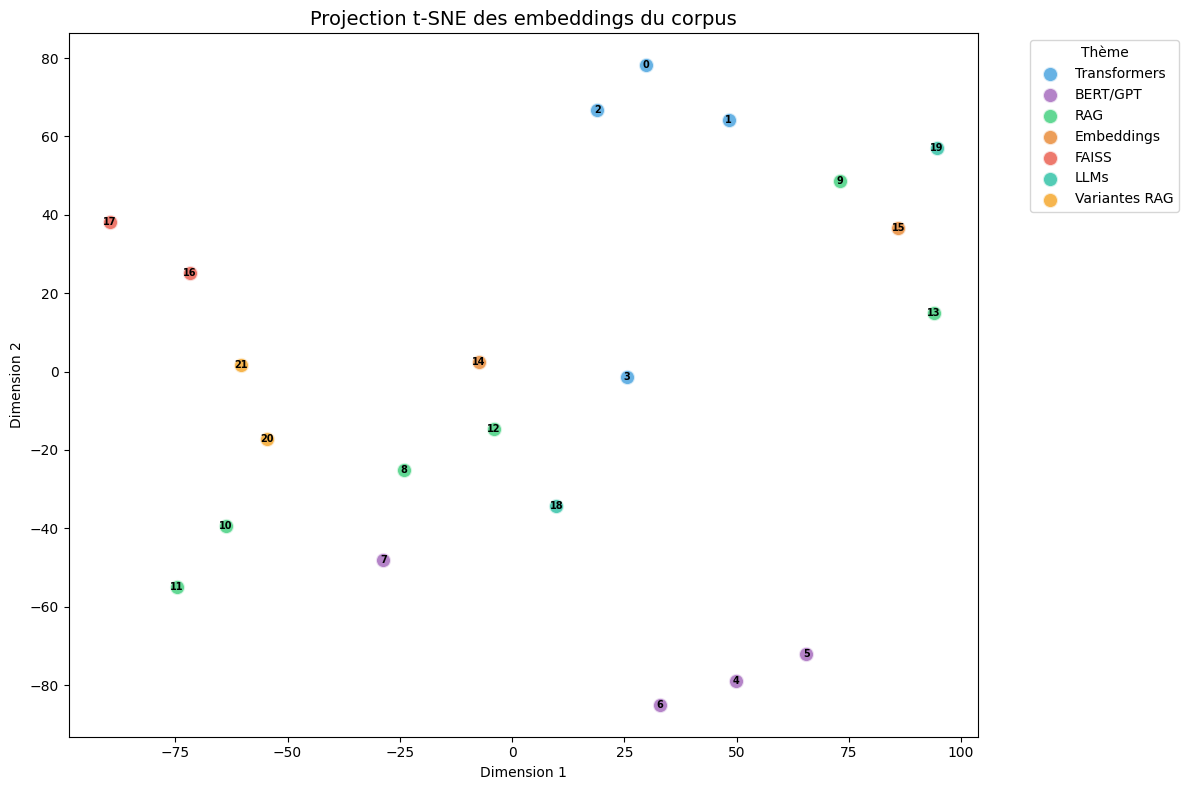

In [46]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Réduction de dimension avec t-SNE
perp = min(5, len(tous_les_chunks) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
embeddings_2d = tsne.fit_transform(document_embeddings)

# Attribution de couleurs par thème (basé sur l'ordre du corpus)
theme_labels = []
theme_colors_map = {
    'Transformers': '#3498db',
    'BERT/GPT': '#9b59b6',
    'RAG': '#2ecc71',
    'Embeddings': '#e67e22',
    'FAISS': '#e74c3c',
    'LLMs': '#1abc9c',
    'Variantes RAG': '#f39c12'
}

# Créer les labels de thème pour chaque chunk
themes = ['Transformers', 'Transformers', 'BERT/GPT', 'BERT/GPT',
          'RAG', 'RAG', 'RAG', 'Embeddings', 'FAISS', 'LLMs', 'Variantes RAG']

# Attribuer le thème à chaque chunk basé sur le document source
chunk_themes = []
chunk_idx = 0
for doc_idx, doc in enumerate(corpus_documents):
    n_chunks_doc = len(decouper_texte(doc, mots_par_chunk=80, chevauchement=20))
    theme = themes[doc_idx] if doc_idx < len(themes) else 'Autre'
    chunk_themes.extend([theme] * n_chunks_doc)

# S'assurer que la liste a la bonne taille
chunk_themes = chunk_themes[:len(tous_les_chunks)]
while len(chunk_themes) < len(tous_les_chunks):
    chunk_themes.append('Autre')

plt.figure(figsize=(12, 8))

unique_themes = list(dict.fromkeys(chunk_themes))
default_colors = ['#3498db', '#9b59b6', '#2ecc71', '#e67e22', '#e74c3c', '#1abc9c', '#f39c12', '#95a5a6']

for i, theme in enumerate(unique_themes):
    mask = [t == theme for t in chunk_themes]
    indices = [j for j, m in enumerate(mask) if m]
    color = default_colors[i % len(default_colors)]
    plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1],
                label=theme, c=color, s=120, alpha=0.75, edgecolors='white', linewidth=1.5)

# Annoter les points
for i in range(len(tous_les_chunks)):
    plt.annotate(f'{i}', (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=7, ha='center', va='center', fontweight='bold')

plt.title("Projection t-SNE des embeddings du corpus", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Thème", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2-e Indexation avec FAISS

Après avoir obtenu les embeddings, nous les ajoutons dans un index vectoriel FAISS.

FAISS permet de rechercher rapidement les chunks dont les embeddings sont les plus proches de l'embedding de la question utilisateur.

In [47]:
dimension = document_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(document_embeddings)

print("Indexation terminée.")
print("Nombre de vecteurs dans FAISS :", index.ntotal)
print("Dimension des vecteurs :", dimension)

Indexation terminée.
Nombre de vecteurs dans FAISS : 22
Dimension des vecteurs : 384


## 2-f Recherche des documents pertinents

Lorsqu'un utilisateur pose une question, nous transformons cette question en embedding.

Ensuite, FAISS recherche les chunks les plus proches de cette question.

Ces chunks constituent le contexte qui sera donné au modèle génératif.

In [48]:
def rechercher_documents_pertinents(requete, k=3):
    requete_embedding = embedder.encode(
        [requete],
        convert_to_numpy=True
    ).astype("float32")

    distances, indices = index.search(requete_embedding, k)

    resultats = []

    for rang, idx in enumerate(indices[0]):
        resultats.append({
            "rang": rang + 1,
            "distance": distances[0][rang],
            "texte": tous_les_chunks[idx]
        })

    return resultats

### Test de recherche

In [49]:
question_test = "Qu'est-ce qu'un système RAG ?"

resultats = rechercher_documents_pertinents(question_test, k=3)

print("Question :", question_test)
print("\nChunks récupérés :")

for res in resultats:
    print(f"\n--- Chunk {res['rang']} | Distance : {res['distance']:.4f} ---")
    print(res["texte"][:300])

Question : Qu'est-ce qu'un système RAG ?

Chunks récupérés :

--- Chunk 1 | Distance : 1.0330 ---
Il existe plusieurs variantes modernes de l'architecture RAG. Le Naive RAG est la version de base avec recherche + génération. L'Advanced RAG ajoute des étapes de pré-traitement (reformulation de requête, re-ranking des résultats). Le Modular RAG décompose le pipeline en modules interchangeables. Le

--- Chunk 2 | Distance : 1.0626 ---
Les avantages du RAG par rapport au fine-tuning sont nombreux. Le fine-tuning nécessite de ré-entraîner le modèle sur de nouvelles données, ce qui est coûteux en temps et en ressources. Le RAG permet de mettre à jour la base de connaissances sans toucher au modèle. De plus, le RAG réduit les halluci

--- Chunk 3 | Distance : 1.0626 ---
en fournissant un contexte externe actualisé.


### Visualisation : Distances FAISS des résultats

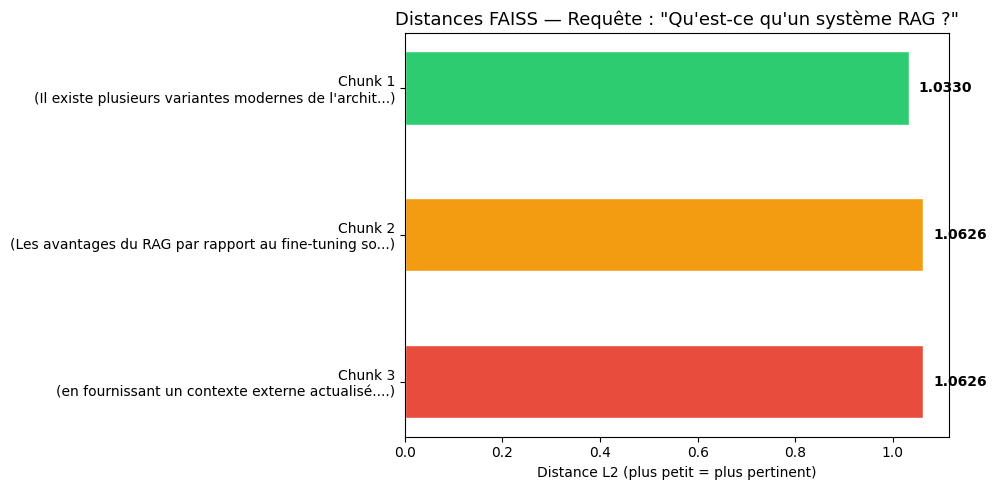

In [50]:
import matplotlib.pyplot as plt

rangs = [f"Chunk {res['rang']}\n({res['texte'][:50]}...)" for res in resultats]
distances = [res['distance'] for res in resultats]

colors_dist = ["#2ecc71", "#f39c12", "#e74c3c"][:len(rangs)]

plt.figure(figsize=(10, 5))
bars = plt.barh(rangs, distances, color=colors_dist, edgecolor='white', height=0.5)

for bar, dist in zip(bars, distances):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{dist:.4f}', va='center', fontweight='bold')

plt.xlabel("Distance L2 (plus petit = plus pertinent)")
plt.title(f'Distances FAISS — Requête : "{question_test}"', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 2-g Génération de réponse avec un prompt augmenté

Après la récupération des chunks pertinents, nous construisons un prompt augmenté.

Le prompt contient :

1. Le contexte récupéré depuis le corpus.
2. La question de l'utilisateur.
3. Une instruction demandant au modèle de répondre uniquement à partir du contexte.

In [51]:
device = 0 if torch.cuda.is_available() else -1

print("Chargement du modèle génératif...")

llm_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",
    device=device
)

print("Modèle génératif chargé.")

Chargement du modèle génératif...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Modèle génératif chargé.


## 2-h Fonction RAG complète

In [52]:
def systeme_rag(question, k=3):
    # 1. Recherche des chunks pertinents
    resultats = rechercher_documents_pertinents(question, k=k)

    # 2. Construction du contexte
    contexte = "\n\n".join([res["texte"] for res in resultats])

    # 3. Construction du prompt augmenté
    prompt = f"""
Réponds à la question en te basant uniquement sur le contexte fourni.

Contexte :
{contexte}

Question :
{question}

Réponse :
"""

    # 4. Génération de la réponse
    reponse = llm_pipeline(
        prompt,
        max_new_tokens=150,
        truncation=True
    )[0]["generated_text"]

    return reponse, resultats, prompt

## 2-i Test du système RAG

In [53]:
question = "Qu'est-ce qu'un système RAG ?"

reponse, sources, prompt_utilise = systeme_rag(question, k=3)

print("Question :", question)
print("\nRéponse générée :")
print(reponse)

print("\nSources utilisées :")
for source in sources:
    print(f"\n--- Source {source['rang']} | Distance : {source['distance']:.4f} ---")
    print(source["texte"][:300])

Question : Qu'est-ce qu'un système RAG ?

Réponse générée :
Describes the RAG architecture.

Sources utilisées :

--- Source 1 | Distance : 1.0330 ---
Il existe plusieurs variantes modernes de l'architecture RAG. Le Naive RAG est la version de base avec recherche + génération. L'Advanced RAG ajoute des étapes de pré-traitement (reformulation de requête, re-ranking des résultats). Le Modular RAG décompose le pipeline en modules interchangeables. Le

--- Source 2 | Distance : 1.0626 ---
Les avantages du RAG par rapport au fine-tuning sont nombreux. Le fine-tuning nécessite de ré-entraîner le modèle sur de nouvelles données, ce qui est coûteux en temps et en ressources. Le RAG permet de mettre à jour la base de connaissances sans toucher au modèle. De plus, le RAG réduit les halluci

--- Source 3 | Distance : 1.0626 ---
en fournissant un contexte externe actualisé.


## 2-j Comparaison avec et sans RAG

Le cahier des charges demande de comparer les réponses obtenues avec et sans RAG.

Sans RAG, le modèle répond uniquement avec ses connaissances internes.

Avec RAG, le modèle reçoit un contexte extrait du corpus avant de générer la réponse.

In [54]:
def repondre_sans_rag(question):
    prompt = f"""
Réponds à la question suivante :

Question :
{question}

Réponse :
"""

    reponse = llm_pipeline(
        prompt,
        max_new_tokens=150,
        truncation=True
    )[0]["generated_text"]

    return reponse

## Comparaison finale

Nous testons plusieurs questions pour comparer les réponses avec et sans RAG.

In [55]:
questions_test = [
    "Qu'est-ce qu'un système RAG ?",
    "Quelle est la différence entre le fine-tuning et le RAG ?",
    "Comment fonctionne le mécanisme d'attention dans les Transformers ?",
    "Quelles sont les limites des LLMs sans RAG ?",
    "Qu'est-ce que FAISS ?",
]

for question in questions_test:
    print("=" * 80)
    print(f"Question : {question}")
    print("=" * 80)

    reponse_sans = repondre_sans_rag(question)
    reponse_avec, sources_rag, _ = systeme_rag(question, k=3)

    print(f"\n--- Réponse SANS RAG ---")
    print(reponse_sans)

    print(f"\n--- Réponse AVEC RAG ---")
    print(reponse_avec)

    print(f"\n--- Sources utilisées ---")
    for source in sources_rag:
        print(f"  Source {source['rang']} | Distance : {source['distance']:.4f}")
        print(f"  {source['texte'][:150]}...")
    print()

Question : Qu'est-ce qu'un système RAG ?

--- Réponse SANS RAG ---
A RAG is a system that is a member of the RAG.

--- Réponse AVEC RAG ---
Describes the RAG architecture.

--- Sources utilisées ---
  Source 1 | Distance : 1.0330
  Il existe plusieurs variantes modernes de l'architecture RAG. Le Naive RAG est la version de base avec recherche + génération. L'Advanced RAG ajoute d...
  Source 2 | Distance : 1.0626
  Les avantages du RAG par rapport au fine-tuning sont nombreux. Le fine-tuning nécessite de ré-entraîner le modèle sur de nouvelles données, ce qui est...
  Source 3 | Distance : 1.0626
  en fournissant un contexte externe actualisé....

Question : Quelle est la différence entre le fine-tuning et le RAG ?

--- Réponse SANS RAG ---
What is the difference between fine-tuning and RAG ?

--- Réponse AVEC RAG ---
The RAG is a model that combines information and language research.

--- Sources utilisées ---
  Source 1 | Distance : 0.5915
  Les avantages du RAG par rapport au fine-t

###  Visualisation : Comparaison des réponses avec et sans RAG

Ce graphique compare la richesse des réponses (en nombre de mots) générées avec et sans RAG
pour chaque question de test.

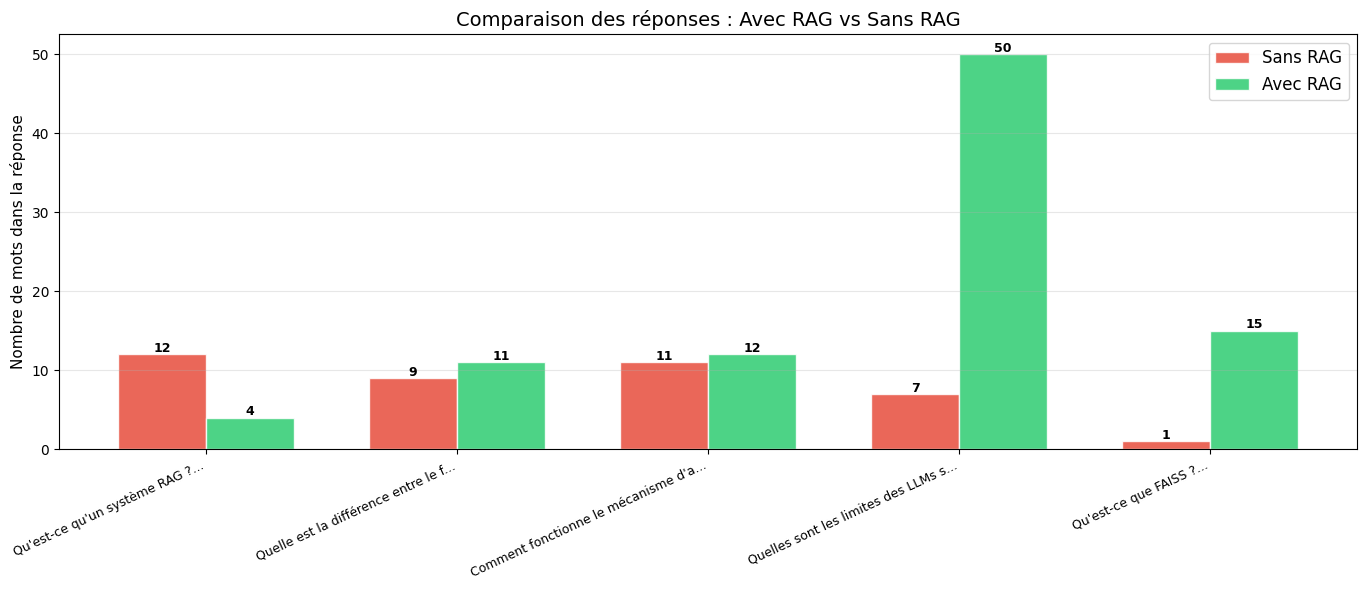


Question                                        Sans RAG   Avec RAG       Gain
Qu'est-ce qu'un système RAG ?...                      12          4         -8
Quelle est la différence entre le f...                 9         11         +2
Comment fonctionne le mécanisme d'a...                11         12         +1
Quelles sont les limites des LLMs s...                 7         50        +43
Qu'est-ce que FAISS ?...                               1         15        +14


In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Collecter les résultats pour chaque question
questions_labels = []
len_sans_rag = []
len_avec_rag = []

for question in questions_test:
    rep_sans = repondre_sans_rag(question)
    rep_avec, _, _ = systeme_rag(question, k=3)

    questions_labels.append(question[:35] + "...")
    len_sans_rag.append(len(rep_sans.split()))
    len_avec_rag.append(len(rep_avec.split()))

# Barplot groupé
x = np.arange(len(questions_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, len_sans_rag, width, label="Sans RAG",
               color="#e74c3c", alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, len_avec_rag, width, label="Avec RAG",
               color="#2ecc71", alpha=0.85, edgecolor='white')

# Ajouter les valeurs sur les barres
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel("Nombre de mots dans la réponse", fontsize=11)
ax.set_title("Comparaison des réponses : Avec RAG vs Sans RAG", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(questions_labels, rotation=25, ha='right', fontsize=9)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n" + "="*80)
print(f"{'Question':<45} {'Sans RAG':>10} {'Avec RAG':>10} {'Gain':>10}")
print("="*80)
for q, s, a in zip(questions_labels, len_sans_rag, len_avec_rag):
    gain = a - s
    print(f"{q:<45} {s:>10} {a:>10} {'+' + str(gain) if gain > 0 else str(gain):>10}")